- Packages import

In [1]:
import numpy as np
import os
import pickle
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.applications import VGG16, InceptionV3, ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, RandomFlip, RandomRotation, RandomZoom, Resizing, Rescaling
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from google.colab import drive


- configuration parameters that will help any modification further to be easily done.

In [2]:
drive.mount('/content/drive')

CONFIG = {
    "DRIVE_DATA_PATH": "/content/drive/MyDrive/master/project-1-deep-learning-image-classification-with-cnn/cifar-10-batches-py",
    "DRIVE_DATA_MODELS_PATH": "/content/drive/MyDrive/master/project-1-deep-learning-image-classification-with-cnn/saved-models",
    "VALIDATION_SPLIT": 0.2,
    "RANDOM_SEED": 42,

    # Augmentation parameters
    "RANDOM_ROTATION": 0.2,
    "RANDOM_ZOOM": 0.1,

    # Model Hyperparameters
    "LEARNING_RATE": 1e-3,
    "OPTIMIZER": Adam,

    # Training Hyperparameters
    "EPOCHS": 3,
    "BATCH_SIZE": 64, # Common sizes: 32, 64, 128

    # Callback Configuration
    "ES_PATIENCE": 10,
    "ES_MONITORED_VARIABLE": "val_loss",
    "RLR_PATIENCE": 5,
    "RLR_FACTOR": 0.2,
    "RLR_MONITORED_VARIABLE": "val_loss",
    "RLR_MIN_LR": 1e-6,

    # Image Configuration
    "IMG_HEIGHT": 32,
    "IMG_WIDTH": 32,
    "IMG_CHANNELS": 3
}


Mounted at /content/drive


- make helper functions to load cifar batches and make transformations reusable for both train and test data.

In [3]:
def load_cifar_batch(filename):
    """ Helper function to load a single batch from pickle file. """
    with open(filename, 'rb') as file:
        data_dict = pickle.load(file, encoding='bytes')
        images = data_dict[b'data']
        labels = data_dict[b'labels']
    return images, labels

def reshape_and_normalize(images_flat):
    """
    Applies the correct reshape and normalization.
    This fixes the "rainbow distorted" image issue.
    """
    # 1. Reshape from (N, 3072) to (N, 3, 32, 32) (channels-first)
    images = images_flat.reshape(-1, 3, CONFIG["IMG_HEIGHT"], CONFIG["IMG_WIDTH"])

    # 2. Transpose from (N, C, H, W) to (N, H, W, C) (channels-last for TF)
    images = images.transpose(0, 2, 3, 1)

    # 3. Normalize pixels to [0, 1]
    images = images.astype('float32') / 255.0
    return images

def load_cifar_data(data_path):
    """
    Loads all CIFAR-10 data (train and test), applies correct
    reshaping, and returns it.
    """
    train_images_flat = []
    train_labels = []

    # Load all 5 training batches
    for i in range(1, 6):
        batch_file = os.path.join(data_path, f'data_batch_{i}')
        batch_images, batch_labels = load_cifar_batch(batch_file)
        train_images_flat.append(batch_images)
        train_labels.extend(batch_labels)

    # Concatenate all training batches
    train_images_flat = np.concatenate(train_images_flat)
    train_labels = np.array(train_labels)

    # Load the single test batch
    test_file = os.path.join(data_path, 'test_batch')
    test_images_flat, test_labels_list = load_cifar_batch(test_file)
    test_labels = np.array(test_labels_list)

    # --- Apply the fix and normalization (Goals 1 & 2) ---
    train_images = reshape_and_normalize(train_images_flat)
    test_images = reshape_and_normalize(test_images_flat)

    # Load label names
    meta_file = os.path.join(data_path, 'batches.meta')
    with open(meta_file, 'rb') as file:
        meta_dict = pickle.load(file, encoding='bytes')
        label_names = [name.decode('utf-8') for name in meta_dict[b'label_names']]

    return (train_images, train_labels), (test_images, test_labels), label_names

- Load data using already built functions.  Make good use of code order and use configuration objects.

In [4]:
print("Loading and preprocessing data...")
(all_train_images, all_train_labels), (test_images, test_labels), LABEL_NAMES = \
    load_cifar_data(CONFIG["DRIVE_DATA_PATH"])

print("Creating validation split...")
train_images, val_images, train_labels, val_labels = train_test_split(
    all_train_images,
    all_train_labels,
    test_size=CONFIG["VALIDATION_SPLIT"],
    random_state=CONFIG["RANDOM_SEED"],
    stratify=all_train_labels
)

print(f"Total training images: {train_images.shape[0]}")
print(f"Total validation images: {val_images.shape[0]}")
print(f"Total test images: {test_images.shape[0]}")

Loading and preprocessing data...
Creating validation split...
Total training images: 40000
Total validation images: 10000
Total test images: 10000


- Display some samples to confirm images load correctly

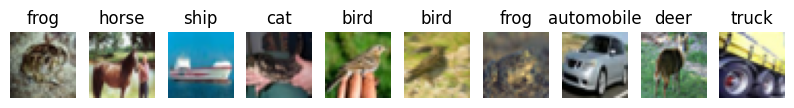

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(train_images[i])
    plt.axis('off')
    plt.title(LABEL_NAMES[train_labels[i]])

plt.show()


- define augmentation object: to train with "more difficult" / distorted, transformed images
- define model

- add helper function that builds model, try to extract any additional configuration parameters.

In [6]:
def build_resnet50_model(CONFIG, num_classes=10, trainable_layers=0):
    """
    Builds a ResNet50 transfer learning model for CIFAR-10.
    """

    input_shape = (CONFIG["IMG_HEIGHT"], CONFIG["IMG_WIDTH"], CONFIG["IMG_CHANNELS"])
    inputs = Input(shape=input_shape)

    # --- 1. Augmentation ---
    x = RandomFlip("horizontal")(inputs)
    x = RandomRotation(CONFIG["RANDOM_ROTATION"])(x)
    x = RandomZoom(CONFIG["RANDOM_ZOOM"])(x)

    # --- 2. Resizing & Preprocessing ---
    x = Resizing(224, 224, interpolation="bilinear")(x)

    # We still "un-normalize" back to [0, 255]
    x = Rescaling(255.0)(x)

    x = preprocess_input(x)

    # --- 3. Base Model (ResNet50) ---
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,  # We don't need the original ImageNet classifier
        input_shape=(224, 224, 3)
    )

    # Freeze the entire base model
    base_model.trainable = False

    # Optionally unfreeze layers
    if trainable_layers > 0:
        trainable_layers = min(trainable_layers, len(base_model.layers))
        for layer in base_model.layers[-trainable_layers:]:
            layer.trainable = True

    x = base_model(x, training=False)

    # --- 4. Classification Head ---
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    # --- 5. Create and Name the Model ---
    model = Model(inputs=inputs, outputs=outputs, name="ResNet50_Transfer_CIFAR10")

    return model

- build and compile model

In [7]:
model_baseline = build_resnet50_model(CONFIG, num_classes=10, trainable_layers=0)
model_baseline.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "ResNet50_Transfer_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 32, 32, 3) │          0 │ input_layer[0][0] │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 32, 32, 3) │          0 │ random_flip[0][0] │
│ (RandomRotation)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 32, 32, 3) │          0 │ random_rotation[… │
│ (RandomZoom)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 224, 224,  │          0 │ random_zoom[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ resizing[0][0]    │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ rescaling[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ rescaling[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ rescaling[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10)        │      5,130 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,643,978 (94.01 MB)

 Trainable params: 1,055,242 (4.03 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

- define callbacks, early stopping (have been working like a charm in the past iteration), reduce on plateau, also I found it more useful and it makes more sense than just the scheduler.

In [8]:
# Use the patience values from CONFIG
callbacks = [
    EarlyStopping(
        monitor=CONFIG["ES_MONITORED_VARIABLE"],
        patience=CONFIG["ES_PATIENCE"],
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor=CONFIG["RLR_MONITORED_VARIABLE"],
        factor=CONFIG["RLR_FACTOR"],
        patience=CONFIG["RLR_PATIENCE"],
        min_lr=CONFIG["RLR_MIN_LR"]
    )
]


### CREATE TF DATASETS
- No augmentation needed here since it's in the model

In [9]:

train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels)) \
    .shuffle(train_images.shape[0]) \
    .batch(CONFIG["BATCH_SIZE"]) \
    .prefetch(tf.data.experimental.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels)) \
    .batch(CONFIG["BATCH_SIZE"]) \
    .prefetch(tf.data.experimental.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels)) \
    .batch(CONFIG["BATCH_SIZE"]) \
    .prefetch(tf.data.experimental.AUTOTUNE)

### TRAIN THE MODEL!

In [10]:
def train_and_evaluate_transfer_model(model, model_name, train_ds, val_ds, test_images, test_labels, label_names):
    print(f"\n=== Training {model_name} ===")

    # Train
    history = model.fit(
        train_ds,
        epochs=CONFIG["EPOCHS"],
        validation_data=val_ds,
        callbacks=callbacks
    )

    # Evaluate
    print(f"\nEvaluating {model_name} on test data...")
    test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=0)
    print(f"{model_name} Test Loss: {test_loss:.4f}")
    print(f"{model_name} Test Accuracy: {test_accuracy*100:.2f}%")

    # Confusion matrix
    print(f"\nGenerating confusion matrix for {model_name}...")
    y_pred_probs = model.predict(test_images)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_labels

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

    # Classification report
    print(classification_report(y_true, y_pred, target_names=label_names))

    # Training curves
    plt.figure(figsize=(15,6))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Val Loss', color='red')
    plt.title(f"{model_name} Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='red')
    plt.title(f"{model_name} Accuracy")
    plt.legend()

    plt.show()

    return history, test_loss, test_accuracy


### FINAL EVALUATION

- illustrate results in confusion matrix

In [11]:
print("Compiling model...")

model_baseline.compile(
    optimizer=CONFIG["OPTIMIZER"](learning_rate=CONFIG["LEARNING_RATE"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 3. Train the baseline model
# We can use your helper function, but we need to capture the model
# and history object from it. Let's just call .fit() directly.
history_stage1 = model_baseline.fit(
    train_dataset,
    epochs=CONFIG["EPOCHS"], # Let EarlyStopping find the best epoch
    validation_data=val_dataset,
    callbacks=callbacks
)

# 4. Save the "warmed-up" weights
model_baseline.save_weights("resnet50_baseline.weights.h5")

print("--- Stage 1 Complete. Baseline weights saved. ---")

print("Model compiled.")

Compiling model...
Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.6207 - loss: 1.1907 - val_accuracy: 0.8488 - val_loss: 0.4477 - learning_rate: 0.0010
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.7342 - loss: 0.7589 - val_accuracy: 0.8723 - val_loss: 0.3732 - learning_rate: 0.0010
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.7414 - loss: 0.7409 - val_accuracy: 0.8709 - val_loss: 0.3755 - learning_rate: 0.0010
--- Stage 1 Complete. Baseline weights saved. ---
Model compiled.


In [12]:
print("--- Starting Stage 2: Fine-Tuning ---")

# 1. Build the fine-tuning model
NUM_TRAINABLE_LAYERS = 33
model_fine_tune = build_resnet50_model(
    CONFIG,
    num_classes=10,
    trainable_layers=NUM_TRAINABLE_LAYERS # Unfreeze the top 33 layers
)

# 2. Load the baseline weights
# This loads our trained head AND the frozen ResNet50 weights
model_fine_tune.load_weights("resnet50_baseline.weights.h5")

# 3. Compile for fine-tuning
FINE_TUNE_LR = 1e-5  # Use a much smaller learning rate
model_fine_tune.compile(
    optimizer=CONFIG["OPTIMIZER"](learning_rate=FINE_TUNE_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"Model re-compiled for fine-tuning with {NUM_TRAINABLE_LAYERS} trainable layers.")

# 4. Train the fine-tuning model
# Let it run for 50 epochs or until EarlyStopping hits
history_ft = model_fine_tune.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks
)

print("--- Fine-Tuning Complete ---")

--- Starting Stage 2: Fine-Tuning ---
Model re-compiled for fine-tuning with 33 trainable layers.
Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 71ms/step - accuracy: 0.7486 - loss: 0.7397 - val_accuracy: 0.8812 - val_loss: 0.3445 - learning_rate: 1.0000e-05
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step - accuracy: 0.7945 - loss: 0.5971 - val_accuracy: 0.8961 - val_loss: 0.3038 - learning_rate: 1.0000e-05
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step - accuracy: 0.8124 - loss: 0.5376 - val_accuracy: 0.9068 - val_loss: 0.2755 - learning_rate: 1.0000e-05
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.8268 - loss: 0.4944 - val_accuracy: 0.9119 - val_loss: 0.2607 - learning_rate: 1.0000e-05
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.8468 - loss: 0.4465 - val_accuracy: 0.9119 - val_loss: 0.2551 - learning_rate: 1.0000e-05
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.8557 - loss: 0.4199 - val_accuracy: 0.9180 -

In [13]:
print("\nEvaluating fine-tuned model...")
test_loss_ft, test_accuracy_ft = model_fine_tune.evaluate(test_dataset)

print(f"Fine-Tuned Test Loss: {test_loss_ft:.4f}")
print(f"Fine-Tuned Test Accuracy: {test_accuracy_ft*100:.2f}%")

# You can now use your helper function's plotting logic on the `history_ft` object
# and `model_fine_tune` to see the new confusion matrix.


Evaluating fine-tuned model...
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9311 - loss: 0.2054
Fine-Tuned Test Loss: 0.2101
Fine-Tuned Test Accuracy: 93.09%


In [14]:
"""
print(f"--- Starting Training for {model.name} ---")

# Call your helper function to do all the work

history, test_loss, test_accuracy = train_and_evaluate_transfer_model(
    model=model,
    model_name=model.name,
    train_ds=train_dataset,
    val_ds=val_dataset,
    test_images=test_images,
    test_labels=test_labels,
    label_names=LABEL_NAMES
)


print("\n--- Training Complete ---")
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy*100:.2f}%")
"""

'\nprint(f"--- Starting Training for {model.name} ---")\n\n# Call your helper function to do all the work\n\nhistory, test_loss, test_accuracy = train_and_evaluate_transfer_model(\n    model=model,\n    model_name=model.name,\n    train_ds=train_dataset,\n    val_ds=val_dataset,\n    test_images=test_images,\n    test_labels=test_labels,\n    label_names=LABEL_NAMES\n)\n\n\nprint("\n--- Training Complete ---")\nprint(f"Final Test Loss: {test_loss:.4f}")\nprint(f"Final Test Accuracy: {test_accuracy*100:.2f}%")\n'


--- Final Evaluation for ResNet50_Transfer_CIFAR10 (Fine-Tuned) ---
Generating confusion matrix...
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step


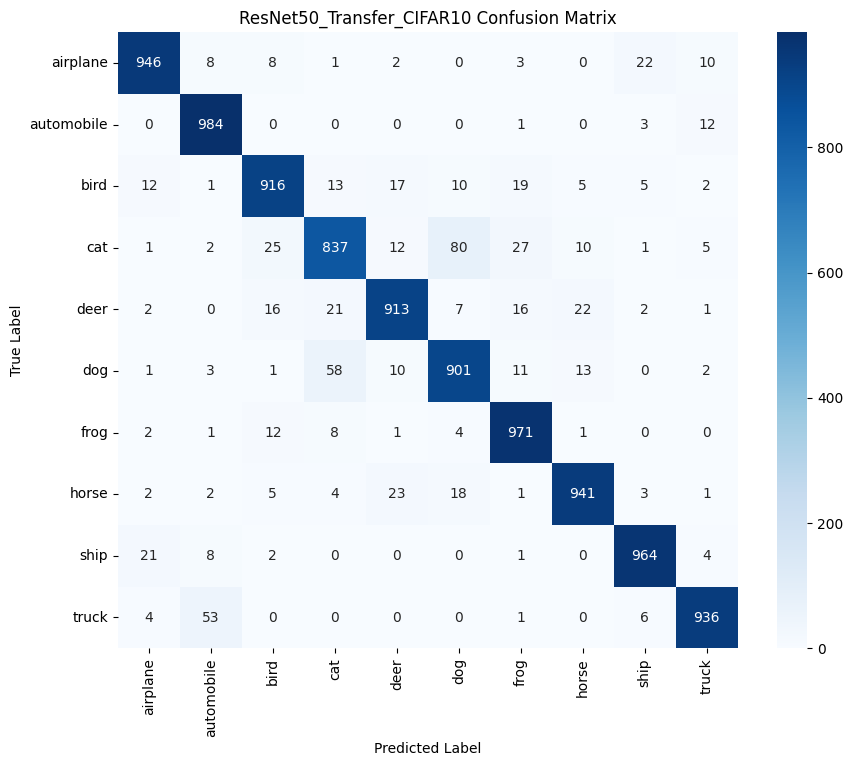

              precision    recall  f1-score   support

    airplane       0.95      0.95      0.95      1000
  automobile       0.93      0.98      0.95      1000
        bird       0.93      0.92      0.92      1000
         cat       0.89      0.84      0.86      1000
        deer       0.93      0.91      0.92      1000
         dog       0.88      0.90      0.89      1000
        frog       0.92      0.97      0.95      1000
       horse       0.95      0.94      0.94      1000
        ship       0.96      0.96      0.96      1000
       truck       0.96      0.94      0.95      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000

Plotting fine-tuning learning curves...


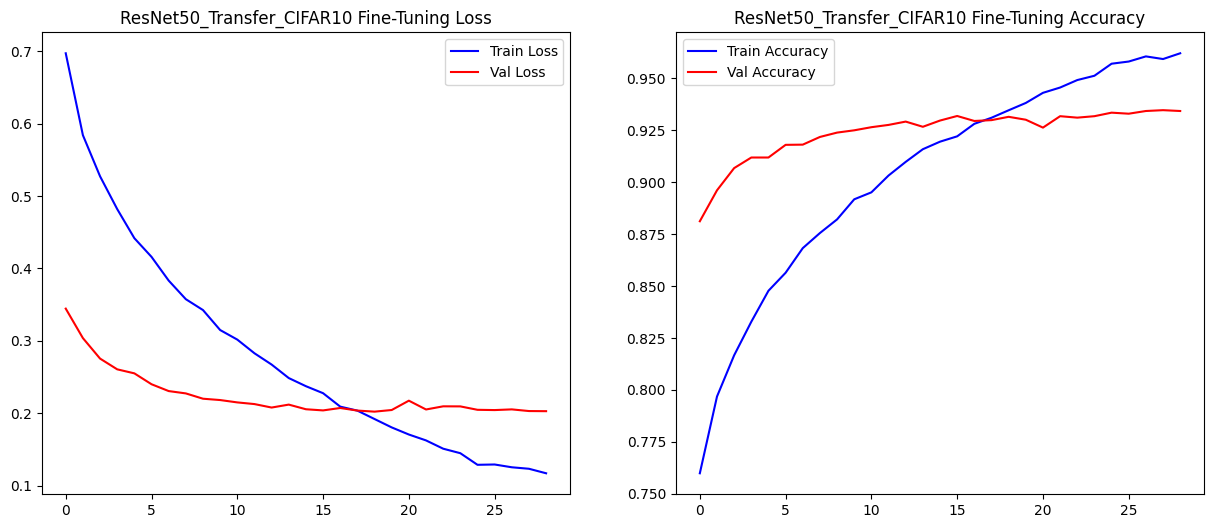

In [15]:
print(f"\n--- Final Evaluation for {model_fine_tune.name} (Fine-Tuned) ---")

# --- 1. Generate Confusion Matrix ---
print("Generating confusion matrix...")
y_pred_probs = model_fine_tune.predict(test_images)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_labels

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES
)
plt.title(f"{model_fine_tune.name} Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# --- 2. Print Classification Report ---
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES))

# --- 3. Plot Training Curves ---
print("Plotting fine-tuning learning curves...")
plt.figure(figsize=(15, 6))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history_ft.history['loss'], label='Train Loss', color='blue')
plt.plot(history_ft.history['val_loss'], label='Val Loss', color='red')
plt.title(f"{model_fine_tune.name} Fine-Tuning Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_ft.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_ft.history['val_accuracy'], label='Val Accuracy', color='red')
plt.title(f"{model_fine_tune.name} Fine-Tuning Accuracy")
plt.legend()

plt.show()